<a href="https://colab.research.google.com/github/TNTD-dev/cs114-crop-recommendation/blob/main/cs114-crop-recommendation/notebooks/%5BCS114%5D_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Import libraries**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler


## **2. Load and Explore the Data**

In [9]:
#https://drive.google.com/file/d/1qkxvblwO9JVABlQGODra_7e3oznFKGun/view?usp=sharing
!gdown 1qkxvblwO9JVABlQGODra_7e3oznFKGun

Downloading...
From: https://drive.google.com/uc?id=1qkxvblwO9JVABlQGODra_7e3oznFKGun
To: /content/Crop_recommendation.csv
100% 150k/150k [00:00<00:00, 113MB/s]


In [10]:
raw = pd.read_csv("/content/Crop_recommendation.csv")

In [11]:
X = raw.drop("label", axis=1)
y =  pd.Series(raw["label"], name="target")

In [12]:
print("Features (X):")
X.head()

Features (X):


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [13]:
print("Target (y):")
y.head()

Target (y):


,target
0,rice
1,rice
2,rice
3,rice
4,rice


In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 120.4 KB


Nhận xét: dataset chỉ có các đặc trưng numerical

In [15]:
numeric_cols = ['N','P','K','temperature','humidity', 'ph', 'rainfall']
categorical_cols = []

In [16]:
X.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## **3. EDA**

In [17]:
print(f"Target gồm các giá trị sau: {y.unique()}")
len(y.unique())

Target gồm các giá trị sau: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


22

| Feature | Description |
|--------|-------------|
| **N** | Ratio of Nitrogen content in soil |
| **P** | Ratio of Phosphorous content in soil |
| **K** | Ratio of Potassium content in soil |
| **temperature** | Temperature in degree Celsius |
| **humidity** | Relative humidity (%) |
| **ph** | pH value of the soil |
| **rainfall** | Rainfall (mm) |
| **label** | 22 Crop type: rice, maize, chickpea, kidneybeans, pigeonpeas, mothbeans, mungbean, blackgram, lentil, pomegranate, banana, mango, grapes, watermelon, muskmelon, apple, orange, papaya, coconut, cotton, jute, coffee |

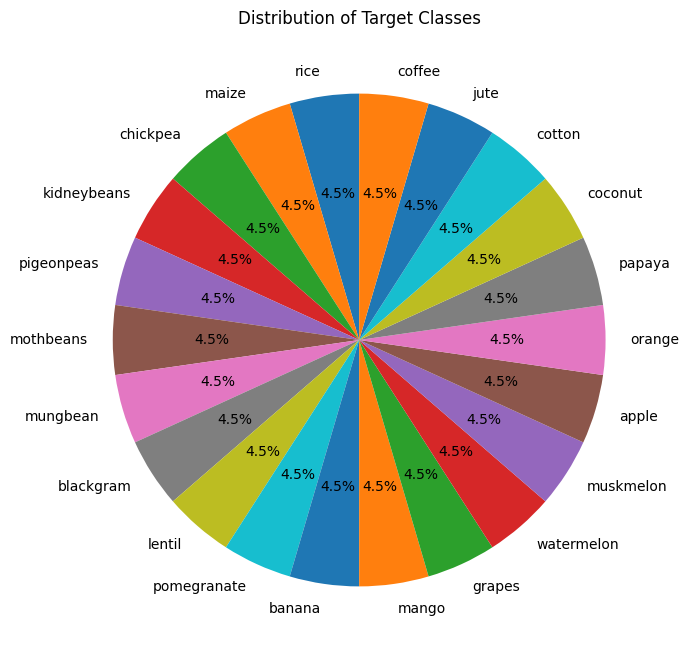

In [18]:
counts = y.value_counts()

# Vẽ pie chart
plt.figure(figsize=(8,8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)

plt.title("Distribution of Target Classes")
plt.show()

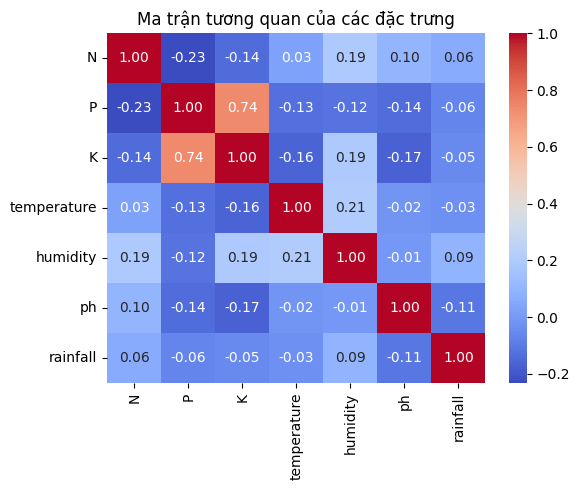

In [19]:
plt.figure(figsize=(6,5))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan của các đặc trưng")
plt.tight_layout()
plt.show()

Historgram của từng đặc trưng


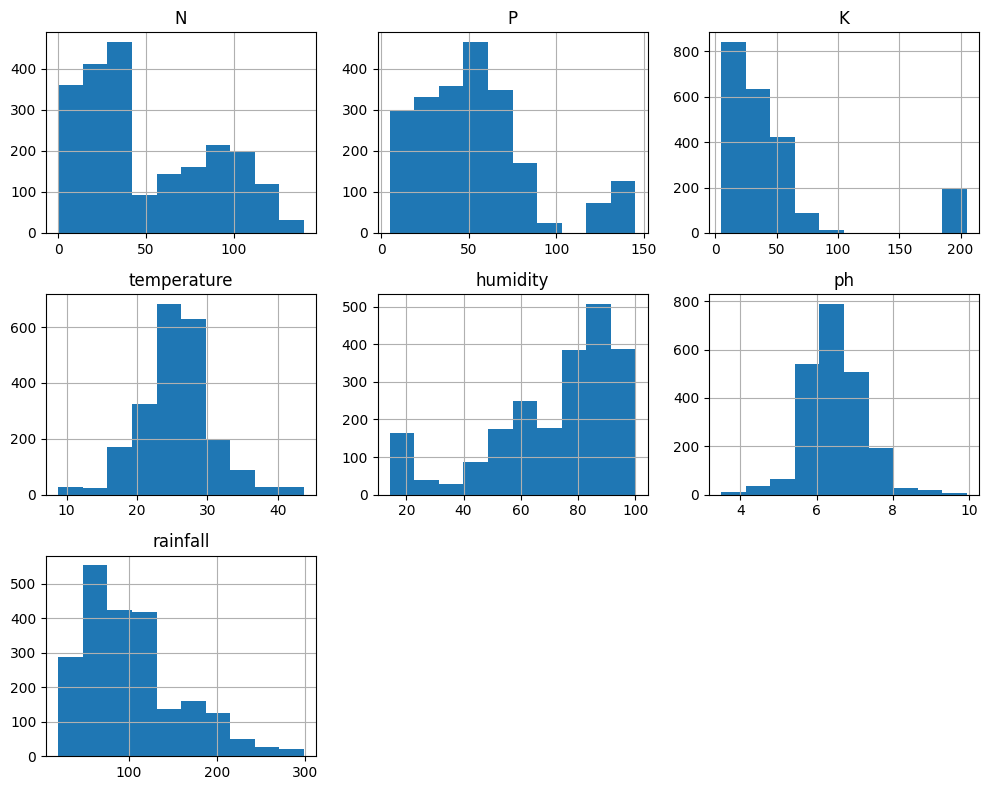

In [20]:
print(f"Historgram của từng đặc trưng")
X.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

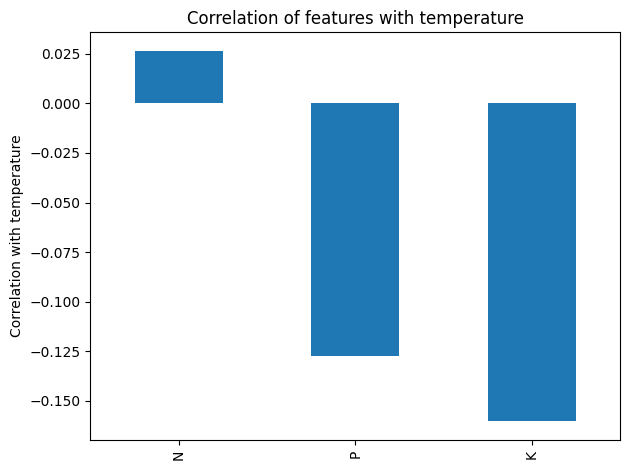

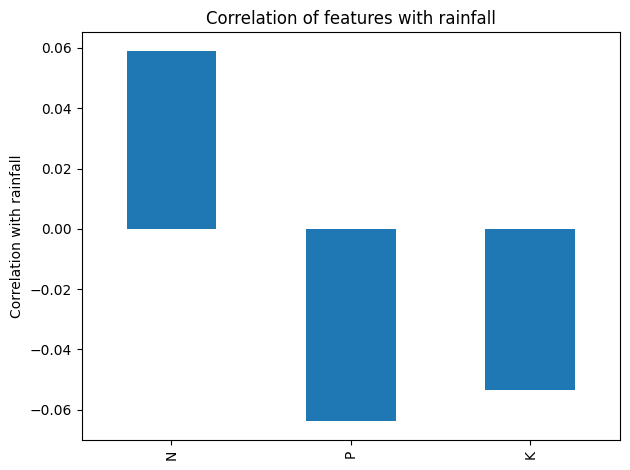

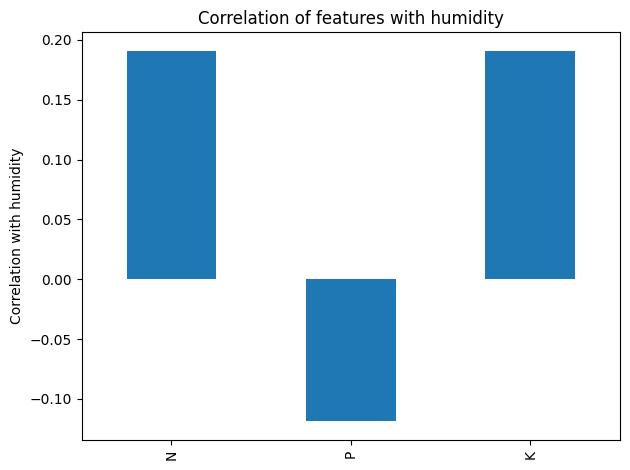

In [21]:
# Correlation with temperature
num_df = X[['temperature','N','P','K']].copy()
corr = num_df.corr(numeric_only=True)['temperature'].drop('temperature')
plt.figure()
corr.plot(kind='bar')
plt.ylabel('Correlation with temperature')
plt.title('Correlation of features with temperature')
plt.tight_layout()
plt.show()

# Correlation with rainfall
num_df = X[['rainfall','N','P','K']].copy()
corr = num_df.corr(numeric_only=True)['rainfall'].drop('rainfall')
plt.figure()
corr.plot(kind='bar')
plt.ylabel('Correlation with rainfall')
plt.title('Correlation of features with rainfall')
plt.tight_layout()
plt.show()

# Correlation with humidity
num_df = X[['humidity','N','P','K']].copy()
corr = num_df.corr(numeric_only=True)['humidity'].drop('humidity')
plt.figure()
corr.plot(kind='bar')
plt.ylabel('Correlation with humidity')
plt.title('Correlation of features with humidity')
plt.tight_layout()
plt.show()

In [22]:
# Check for missing values and data types
print("\nMissing Values:\n", X.isnull().sum())
print("\nDuplicated Rows:", X.duplicated().sum())


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
dtype: int64

Duplicated Rows: 0


## **4. Data Preprocessing**

In [23]:
TARGET = 'label'
raw_feature_cols = [c for c in raw.columns if c != TARGET]
K = len(raw_feature_cols)

X_all = raw[raw_feature_cols]
y_all = raw[TARGET]

cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MinMaxScaler())
])
num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocess = ColumnTransformer([
    ('num', num_proc, numeric_cols),
])

raw_pipeline = Pipeline([
    ('preprocess', preprocess),
])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

X_raw_train = raw_pipeline.fit_transform(X_train, y_train)
X_raw_val = raw_pipeline.transform(X_val)
X_raw_test = raw_pipeline.transform(X_test)

# Get the feature names after preprocessing
preprocessed_feature_names = []
for name, transformer, columns in preprocess.transformers_:
    if hasattr(transformer, 'get_feature_names_out'):
        preprocessed_feature_names.extend(transformer.get_feature_names_out(columns))
    else:
        preprocessed_feature_names.extend(columns)

# Convert NumPy arrays to DataFrames
X_raw_train_df = pd.DataFrame(X_raw_train, columns=preprocessed_feature_names, index=X_train.index)
X_raw_val_df = pd.DataFrame(X_raw_val, columns=preprocessed_feature_names, index=X_val.index)
X_raw_test_df = pd.DataFrame(X_raw_test, columns=preprocessed_feature_names, index=X_test.index)


out_dir = Path('splits'); out_dir.mkdir(parents=True, exist_ok=True)
pd.concat([X_raw_train_df, y_train.rename(TARGET)], axis=1).to_csv(out_dir / 'raw_train.csv', index=False)
pd.concat([X_raw_val_df, y_val.rename(TARGET)], axis=1).to_csv(out_dir / 'raw_val.csv', index=False)
pd.concat([X_raw_test_df, y_test.rename(TARGET)], axis=1).to_csv(out_dir / 'raw_test.csv', index=False)
print("Saved RAW splits. K (RAW features) =", K)

display(X_raw_train_df)
display(X_raw_train_df.isna().sum())

Saved RAW splits. K (RAW features) = 7


,N,P,K,temperature,humidity,ph,rainfall
1607,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1212,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
362,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
566,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
1671,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941
...,...,...,...,...,...,...,...
808,-1.018869,0.323643,-0.555154,-1.274842,-0.396933,0.149081,-1.218366
422,-0.937463,0.050404,-0.574880,-1.194399,-1.087561,-0.076988,1.618598
2052,0.853467,-0.162115,-0.239537,0.036250,0.464759,-0.155483,1.633233
2083,1.070550,-0.101395,-0.081729,0.257343,0.092922,-0.281484,1.237246


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0


### **4.1 Feature Engineering**

| New Feature      | Formula / Method                                      | Purpose                              |
|------------------|--------------------------------------------------------|--------------------------------------|
| **NPK_mean**     | (N + P + K) / 3                                        | Average soil nutrient level          |
| **THI**          | (temperature × humidity) / 100                         | Temperature–Humidity stress index    |
| **ph_category**  | Bins: <5.5 → Acidic, 5.5–7.5 → Neutral, >7.5 → Alkaline | Soil acidity classification          |
| **rainfall_level** | Bins: 0–50 Low, 50–100 Medium, 100–200 High, >200 Very High | Categorical rainfall intensity |

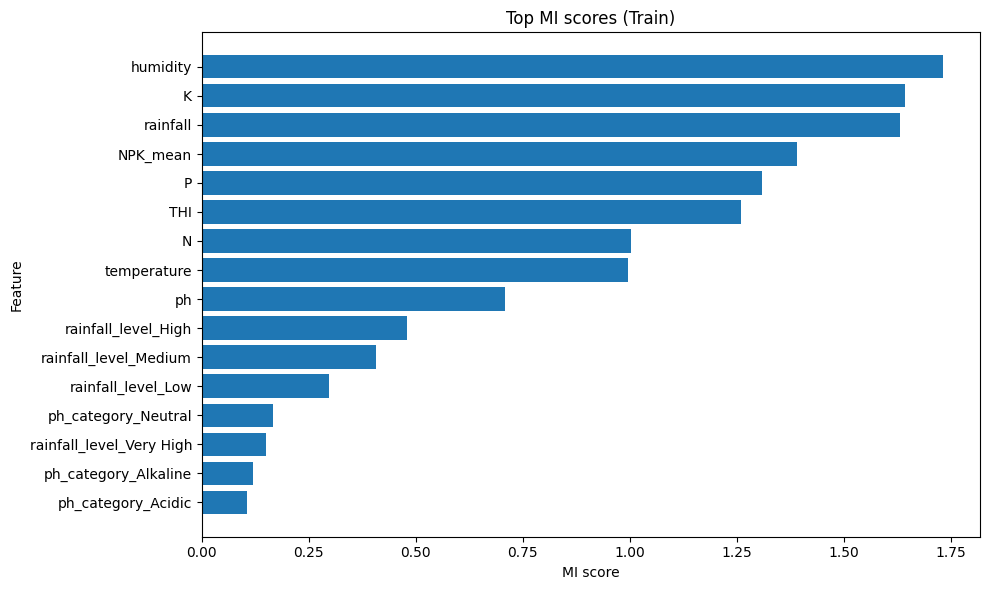

Selected TOP-K engineered features (K = RAW features): 7


,fe_topk_features
0,humidity
1,K
2,rainfall
3,NPK_mean
4,P
5,THI
6,N


Saved FE splits. K (FE features) = 7


In [24]:
def add_new_features(Xdf):
    Xdf = Xdf.copy()

    # 1) NPK_mean = (N + P + K) / 3
    if {'N', 'P', 'K'}.issubset(Xdf.columns):
        Xdf['NPK_mean'] = (Xdf['N'] + Xdf['P'] + Xdf['K']) / 3

    # 2) THI = (temperature * humidity) / 100
    if {'temperature', 'humidity'}.issubset(Xdf.columns):
        Xdf['THI'] = (Xdf['temperature'] * Xdf['humidity']) / 100

    # 3) ph_category
    if 'ph' in Xdf.columns:
        Xdf['ph_category'] = pd.cut(
            Xdf['ph'],
            bins=[-np.inf, 5.5, 7.5, np.inf],
            labels=['Acidic', 'Neutral', 'Alkaline'],
            include_lowest=True
        ).astype('category')

    # 4) rainfall_level
    if 'rainfall' in Xdf.columns:
        Xdf['rainfall_level'] = pd.cut(
            Xdf['rainfall'],
            bins=[0, 50, 100, 200, np.inf],
            labels=['Low', 'Medium', 'High', 'Very High'],
            include_lowest=True
        ).astype('category')

    return Xdf

generated_nums = ['NPK_mean', 'THI']
generated_cats = ['ph_category', 'rainfall_level']

all_nums = numeric_cols + generated_nums
all_cats = categorical_cols + generated_cats

cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer([
    ('num', num_proc, all_nums),
    ('cat', cat_proc, all_cats),
])

feature_adder = FunctionTransformer(add_new_features, validate=False)

fe_pipeline = Pipeline([
    ('add_features', feature_adder),
    ('preprocess', preprocess),
    ('var_filter', VarianceThreshold(threshold=0.0))
])

Xt_tr_np = fe_pipeline.fit_transform(X_train, y_train)
Xt_va_np = fe_pipeline.transform(X_val)
Xt_te_np = fe_pipeline.transform(X_test)

# Lấy tên cột sau OneHot
ohe = fe_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_names = list(ohe.get_feature_names_out(all_cats))

pre_names = list(all_nums) + cat_names
mask = fe_pipeline.named_steps['var_filter'].get_support()
eng_cols = [name for name, keep in zip(pre_names, mask) if keep]

Xt_tr = pd.DataFrame(Xt_tr_np, columns=eng_cols, index=X_train.index)
Xt_va = pd.DataFrame(Xt_va_np, columns=eng_cols, index=X_val.index)
Xt_te = pd.DataFrame(Xt_te_np, columns=eng_cols, index=X_test.index)

# Đánh dấu các cột rời rạc sau OneHot
cat_prefixes = tuple(f"{col}_" for col in all_cats)
is_discrete = np.array(
    [col.startswith(cat_prefixes) for col in Xt_tr.columns],
    dtype=bool
)

mi_scores = mutual_info_classif(
    Xt_tr.values,
    y_train.values,
    discrete_features=is_discrete,
    random_state=42
)
mi_series = pd.Series(mi_scores, index=Xt_tr.columns).sort_values(ascending=False)

# Visualize Top MI
topN = int(min(20, len(mi_series)))
top_mi = mi_series.head(topN).iloc[::-1]

plt.figure(figsize=(10, max(6, 0.35 * topN)))
plt.barh(top_mi.index, top_mi.values)
plt.title('Top MI scores (Train)')
plt.xlabel('MI score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

K = len([c for c in raw.columns if c != 'label'])
topk_cols = list(mi_series.head(K).index)

print("Selected TOP-K engineered features (K = RAW features):", K)
display(pd.Series(topk_cols, name="fe_topk_features").reset_index(drop=True))

fe_tr = Xt_tr[topk_cols].copy()
fe_tr['label'] = y_train.values

fe_va = Xt_va[topk_cols].copy()
fe_va['label'] = y_val.values

fe_te = Xt_te[topk_cols].copy()
fe_te['label'] = y_test.values

out_dir = Path('splits')
out_dir.mkdir(parents=True, exist_ok=True)

fe_tr.to_csv(out_dir / 'fe_train.csv', index=False)
fe_va.to_csv(out_dir / 'fe_val.csv', index=False)
fe_te.to_csv(out_dir / 'fe_test.csv', index=False)

print("Saved FE splits. K (FE features) =", K)

In [25]:
display(fe_tr.head())
display(fe_tr.isna().sum())

,humidity,K,rainfall,NPK_mean,P,THI,N,label
1607,0.924395,-0.673510,0.199440,-1.499135,-1.072910,1.263240,-1.371628,orange
1212,0.426613,3.015261,-0.643677,2.247744,2.084513,0.772089,-1.127411,grapes
362,-2.186291,-0.476250,0.694001,-0.574905,0.536162,-1.952700,-1.073140,kidneybeans
566,-0.459237,-0.594606,-1.231744,-0.724780,-0.465713,-0.344523,-0.340487,mothbeans
1671,0.915842,-0.791866,0.289941,-1.424197,-1.255069,-0.990602,-0.883193,orange


,0
humidity,0
K,0
rainfall,0
NPK_mean,0
P,0
THI,0
N,0
label,0


In [26]:
# zip folder
!zip -r dataset.zip splits

  adding: splits/ (stored 0%)
  adding: splits/fe_train.csv (deflated 68%)
  adding: splits/raw_test.csv (deflated 60%)
  adding: splits/fe_val.csv (deflated 61%)
  adding: splits/raw_train.csv (deflated 65%)
  adding: splits/fe_test.csv (deflated 61%)
  adding: splits/raw_val.csv (deflated 60%)
